In [1]:
# ── Portable environment bootstrap · local ↔ Kaggle ──────────────────────────
# No-op on my machine (the notebook already runs from notebooks/, so ../data and
# ../reports resolve). On Kaggle it rebuilds that layout: it finds the cleaned
# dataset file whatever its name/compression (Kaggle may rename or extract it),
# detects the real format from the file's magic bytes, and materialises it at
# ../data/processed/df_clean.csv — so every relative path below keeps working.
import os, glob, gzip, zipfile, shutil
from pathlib import Path

if Path('/kaggle/input').exists():
    work   = Path('/kaggle/working')
    nb_dir = work / 'notebooks'
    nb_dir.mkdir(exist_ok=True)
    os.chdir(nb_dir)                                   # now '..' == /kaggle/working
    proc = work / 'data' / 'processed'
    proc.mkdir(parents=True, exist_ok=True)
    (work / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

    target = proc / 'df_clean.csv'
    if not target.exists():
        cands = [c for c in glob.glob('/kaggle/input/**/df_clean*', recursive=True)
                 if os.path.isfile(c)]
        if not cands:
            raise FileNotFoundError(
                "No df_clean.* file in the attached dataset — attach the Cyclistic dataset.")
        # prefer a real .csv, else the largest candidate
        csvs = [c for c in cands if c.lower().endswith('.csv')]
        src  = csvs[0] if csvs else max(cands, key=os.path.getsize)

        with open(src, 'rb') as f:
            magic = f.read(2)
        if magic == b'\x1f\x8b':                       # gzip
            with gzip.open(src, 'rb') as fi, open(target, 'wb') as fo:
                shutil.copyfileobj(fi, fo)
        elif magic == b'PK':                            # real zip archive
            with zipfile.ZipFile(src) as z:
                inner = [n for n in z.namelist() if n.lower().endswith('.csv')] or z.namelist()
                with z.open(inner[0]) as fi, open(target, 'wb') as fo:
                    shutil.copyfileobj(fi, fo)
        else:                                           # already plain-text CSV
            os.symlink(src, target)
        print(f"Kaggle detected — df_clean.csv ready (from {os.path.basename(src)})")
    else:
        print("Kaggle detected — df_clean.csv already present.")
else:
    print("Local environment — using the existing ../data and ../reports layout.")


Local environment — using the existing ../data and ../reports layout.


# Casual-to-Member Conversion Strategy
### Behavioral Segmentation · Cyclistic Chicago · Jun 2025 – May 2026

> Ride-level data · 5.8 M trips · No persistent user ID

<a id='toc'></a>
## Contents

1. [Business Question](#objective)
2. [Data & Preparation](#data)
3. [Casual vs. Member: First Look](#eda)
4. [Segmentation into Subgroups](#clustering)
5. [Subgroup Profiles](#profiling)
   - [Are Members Homogeneous?](#members_homo)
   - [All Subgroups at a Glance](#all_subgroups)
6. [Similarity, Volume & Conversion Priority](#similarity)
   - [6.1 Similarity to Member Behaviour](#sim_score)
   - [6.2 Ride Volume by Subgroup](#volume)
   - [6.3 Conversion Priority](#priority)
   - [E-Bike Usage Among Commute E-Bike Riders](#ebike_pm)
7. [Per-Subgroup Breakdown](#insights)
8. [Conclusions & Recommendations](#conclusions)
9. [Limitations](#limits)

---

---
## 1 · Business Question <a id='objective'></a>

Cyclistic is a Chicago bike-share service with two user types: **casual riders**
(single ride or day pass) and **annual members** (flat-rate subscription).
The marketing team's hypothesis is that converting high-potential casual riders
into annual members is the most cost-effective growth lever.

Three questions drive this analysis:
1. How do casual riders actually behave differently from annual members?
2. Are casual riders one uniform group, or do distinct behavioural profiles exist within them?
3. Which profiles are structurally closest to member behaviour — and large enough to be worth targeting?

> **Note:** segmentation is at ride level, not customer level. No persistent user ID
> is available, so clusters describe patterns of behaviour, not individual people.

[↑ back to top](#toc)

---
## 2 · Data & Preparation <a id='data'></a>

The raw data is one row per ride — timestamps, GPS coordinates, bike type, user type.
Before the analysis, I derive a set of behavioural features from the raw fields.

| Feature | Description |
|---------|-------------|
| `trip_duration_min` | Ride length in minutes |
| `distance_km` | Straight-line distance (haversine) |
| `avg_speed_kmh` | Approximate average speed |
| `is_weekend` | 1 if Saturday or Sunday |
| `is_commute` | 1 if weekday departure 7–9 AM or 5–7 PM |
| `is_nonworking` | 1 if weekend or Illinois public holiday |
| `season` | Meteorological season |

### Quality Checks

[↑ back to top](#toc)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import holidays

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
DATA_FILE = BASE_DIR / 'data' / 'processed' / 'df_clean.csv'
FIG_DIR   = BASE_DIR / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  PALETTE VISIVA — unica e coerente per tutto il notebook
#
#  Logica semantica:
#    • Blu profondo  → member / comportamento più vicino ai member
#    • Blu medio     → comportamento parzialmente simile ai member
#    • Grigio neutro → comportamento più distante dai member
#    • Ambra         → casual aggregato (colore d'accento caldo)
#
#  Il colore racconta già la storia: più è blu, più il gruppo assomiglia
#  ai member annuali. Il grigio segnala distanza comportamentale.
# ══════════════════════════════════════════════════════════════════════════════

MEMBER_COLOR = '#2962A6'   # blu profondo  — benchmark member
CASUAL_COLOR = '#C06A2C'   # ambra         — casual aggregato

# Sottogruppi casual: assegnazione per nome (semantica, non per indice)
SUBGROUP_COLORS = {
    'Commute-Pattern Riders':    '#2962A6',  # blu — più vicino ai member
    'Mixed Urban Riders':        '#7AA3C8',  # blu medio — somiglianza moderata
    'Weekend Leisure Explorers': '#B0BEC5',  # grigio neutro — più distante
}

# Variante per deduplicazione automatica dei nomi (es. "... (A)")
def subgroup_color(name: str) -> str:
    """
    Semantic color assignment based on dominant trait in the name.
    Blu  → commuting pattern (most member-like behavior)
    Grigio → weekend-dominant (least member-like behavior)
    Blu medio → everything else (moderate similarity)
    This keyword-based approach is robust to name changes across runs.
    """
    n = name.lower()
    if 'commute' in n:
        return '#2962A6'   # blue  — commute pattern = most similar to members
    elif 'weekend' in n:
        return '#B0BEC5'   # grey  — weekend-only = most distant from members
    else:
        return '#7AA3C8'   # mid-blue — intermediate profile

# Priorità marketing
PRIORITY_COLORS = {
    'High':   '#2962A6',
    'Medium': '#7AA3C8',
    'Low':    '#B0BEC5',
}

# Palette generica casual vs member (per grafici EDA)
PALETTE = {'member': MEMBER_COLOR, 'casual': CASUAL_COLOR}

# Member subgroups — blue family più chiara
MEMBER_SUBGROUP_COLORS = ['#1A4A80', '#3C76B4', '#7AAAD0']

# ── Stile globale matplotlib ───────────────────────────────────────────────────
sns.set_theme(style='white', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi':           130,
    'axes.titlesize':       12,
    'axes.titleweight':     'bold',
    'axes.labelsize':       10,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.spines.left':     False,
    'axes.grid':            True,
    'axes.grid.axis':       'x',
    'grid.color':           '#EBEBEB',
    'grid.linewidth':       0.8,
    'xtick.bottom':         False,
    'ytick.left':           False,
    'legend.framealpha':    0.9,
    'legend.edgecolor':     '#DDDDDD',
    'figure.facecolor':     'white',
    'axes.facecolor':       'white',
})

print('Librerie e palette caricate.')
print(f'  Member color   : {MEMBER_COLOR}')
print(f'  Casual color   : {CASUAL_COLOR}')
print(f'  Subgroup colors: {list(SUBGROUP_COLORS.values())}')

Librerie e palette caricate.
  Member color   : #2962A6
  Casual color   : #C06A2C
  Subgroup colors: ['#2962A6', '#7AA3C8', '#B0BEC5']


In [3]:
df = pd.read_csv(DATA_FILE, parse_dates=['started_at', 'ended_at'], low_memory=False)

# Basic temporal enrichment
df['trip_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df = df[(df['trip_duration_min'] > 0) & (df['trip_duration_min'] < 1440)].copy()

df['hour']        = df['started_at'].dt.hour
df['month']       = df['started_at'].dt.month
df['year']        = df['started_at'].dt.year
df['weekday_num'] = df['started_at'].dt.dayofweek   # 0=Mon, 6=Sun

n_total  = len(df)
n_casual = (df['member_casual'] == 'casual').sum()
n_member = (df['member_casual'] == 'member').sum()

print(f"Dataset loaded: {n_total:,} rides")
print(f"  Casual : {n_casual:,} ({n_casual/n_total*100:.1f}%)")
print(f"  Member : {n_member:,} ({n_member/n_total*100:.1f}%)")
print(f"  Period : {df['started_at'].min().date()} → {df['started_at'].max().date()}")


Dataset loaded: 5,841,731 rides
  Casual : 2,094,747 (35.9%)
  Member : 3,746,984 (64.1%)
  Period : 2025-06-01 → 2026-05-31


In [4]:
# Missing values
miss = df.isnull().sum()
print("=== Missing values ===")
print(miss[miss > 0].to_string() if miss[miss > 0].any() else "  None — dataset is complete.")

# Duration sanity
print("\nRide duration by user type (min):")
print(df.groupby('member_casual')['trip_duration_min']
        .agg(['median','mean','std']).round(1).rename(columns={'median':'median','mean':'mean','std':'std'}).to_string())

# Ride-ID uniqueness
dupes = df['ride_id'].duplicated().sum()
print(f"\nDuplicate ride IDs: {dupes} {'✓' if dupes==0 else '⚠️'}")
print(f"Rideable types: {sorted(df['rideable_type'].unique())}")

=== Missing values ===
start_station_name    1249485
start_station_id      1249485
end_station_name      1308152
end_station_id        1308152

Ride duration by user type (min):


               median  mean   std
member_casual                    
casual           11.2  18.8  37.3
member            8.6  12.0  21.3

Duplicate ride IDs: 0 ✓


Rideable types: ['classic_bike', 'electric_bike']


In [5]:
# Station columns: verify nulls come exclusively from electric bikes
# Electric bikes can be parked at any public rack (free-floating) → no station ID recorded.
# Classic bikes must be returned to a docking station → a null here would be a real data issue.
STATION_COLS = ['start_station_name', 'start_station_id',
                'end_station_name',   'end_station_id']

has_null_station = df[STATION_COLS].isnull().any(axis=1)
null_by_type     = df[has_null_station]['rideable_type'].value_counts()
classic_nulls    = null_by_type.get('classic_bike', 0)

print(f"Station nulls — rides affected: {has_null_station.sum():,} ({has_null_station.mean()*100:.1f}%)")
print(null_by_type.to_string())
if classic_nulls == 0:
    print("\n✓ All missing station values belong to electric bikes — structurally expected.")
elif classic_nulls < 100:
    print(f"\n✓ Only {classic_nulls:,} classic-bike rides with missing station data.")
else:
    print(f"\n⚠️ {classic_nulls:,} classic-bike rides with missing station data — investigate.")

Station nulls — rides affected: 1,964,029 (33.6%)
rideable_type
electric_bike    1964025
classic_bike           4

✓ Only 4 classic-bike rides with missing station data.


Electric bikes are *free-floating* — they can be parked at any public rack, so no station ID
is recorded when a ride ends outside a dock. Classic bikes, on the other hand, must always
return to a docking station, so a null in those rows would be a genuine data problem.

The check confirms it: apart from a handful of classic-bike rides (4 out of 1.9M affected
rows — negligible), every missing station value belongs to an electric bike ride.
These values are absent by design, not by mistake.

> One important caveat throughout: segmentation is at **ride level**.
> The same real-world user may appear in different clusters depending on context
> (weekday commute vs. weekend ride). Keep this in mind when interpreting subgroup sizes.

### Feature Engineering

Two features need a bit of explanation since they appear consistently throughout the notebook:

- **Commute window:** a ride is flagged as commute-adjacent if it departs on a weekday
  between 7–9 AM (arriving at work by 9) or 5–7 PM (leaving work at 5).
- **Holiday detection:** Illinois public holidays are identified automatically via the
  `holidays` library. The `is_nonworking` flag combines weekends and holidays into one indicator.

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized haversine great-circle distance in km."""
    R = 6371.0
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = la2 - la1, lo2 - lo1
    a = np.sin(dlat/2)**2 + np.cos(la1) * np.cos(la2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['distance_km'] = haversine_km(
    df['start_lat'].values, df['start_lng'].values,
    df['end_lat'].values,   df['end_lng'].values
)

# Speed: avoid division by zero for rides < 30 seconds
df['avg_speed_kmh'] = np.where(
    df['trip_duration_min'] >= 0.5,
    (df['distance_km'] / df['trip_duration_min'] * 60).clip(upper=40.0),
    0.0
)

print("Distance and speed computed.")
print(df.groupby('member_casual')[['distance_km','avg_speed_kmh']].median().round(2).to_string())
print(f"Zero-distance rides: {(df['distance_km']==0).sum():,} ({(df['distance_km']==0).mean()*100:.1f}%)")


Distance and speed computed.


               distance_km  avg_speed_kmh
member_casual                            
casual                1.61           9.83
member                1.62          12.31
Zero-distance rides: 364,756 (6.2%)


In [7]:
# Time-of-day slot
TIME_SLOT_MAP = {0:'Night', 1:'Morning', 2:'Midday', 3:'Afternoon', 4:'Evening'}
def _slot(h):
    if h < 6:    return 0
    elif h < 10: return 1
    elif h < 16: return 2
    elif h < 20: return 3
    else:        return 4

df['time_slot']   = df['hour'].map(_slot)

# Weekend & broad peak-hour flags
df['is_weekend']   = (df['weekday_num'] >= 5).astype(int)
df['is_peak_hour'] = (
    (df['weekday_num'] < 5) &
    df['hour'].isin(list(range(7, 10)) + list(range(16, 20)))
).astype(int)

# ── Commute feature (declared windows) ────────────────────────────────────────
# AM commute: weekday departure 07:00–08:59  → consistent with work start ~09:00
# PM commute: weekday departure 17:00–18:59  → consistent with work end   ~17:00
COMMUTE_AM = (7, 9)   # [start_hour_inclusive, end_hour_exclusive)
COMMUTE_PM = (17, 19)

df['is_commute'] = (
    (df['weekday_num'] < 5) &
    (
        df['hour'].between(COMMUTE_AM[0], COMMUTE_AM[1] - 1) |
        df['hour'].between(COMMUTE_PM[0], COMMUTE_PM[1] - 1)
    )
).astype(int)

# Season  (Northern Hemisphere meteorological)
SEASON_MAP = {1:'Spring', 2:'Summer', 3:'Autumn', 4:'Winter'}
def _season(m):
    if m in [3, 4, 5]:    return 1
    elif m in [6, 7, 8]:   return 2
    elif m in [9, 10, 11]: return 3
    else:                  return 4

df['season']      = df['month'].map(_season)
df['is_electric'] = (df['rideable_type'] == 'electric_bike').astype(int)

# Feature set: is_commute replaces is_peak_hour in the cluster model.
# is_commute is a tighter, more semantically precise commuting proxy.
# is_peak_hour is retained in the dataframe for EDA and profiling.
CLUSTER_FEATURES = ['trip_duration_min', 'distance_km', 'avg_speed_kmh',
                    'is_weekend', 'is_commute', 'time_slot', 'season', 'is_electric']

print("Time & commute features computed.")
print(f"\nWeekend share   : casual={df[df.member_casual=='casual']['is_weekend'].mean()*100:.1f}%  "
      f"member={df[df.member_casual=='member']['is_weekend'].mean()*100:.1f}%")
print(f"Peak-hour share : casual={df[df.member_casual=='casual']['is_peak_hour'].mean()*100:.1f}%  "
      f"member={df[df.member_casual=='member']['is_peak_hour'].mean()*100:.1f}%")
print(f"Commute share   : casual={df[df.member_casual=='casual']['is_commute'].mean()*100:.1f}%  "
      f"member={df[df.member_casual=='member']['is_commute'].mean()*100:.1f}%")


Time & commute features computed.



Weekend share   : casual=37.7%  member=23.6%


Peak-hour share : casual=29.5%  member=43.2%


Commute share   : casual=17.4%  member=27.5%


In [8]:
# ── Public holiday detection (Illinois / Chicago) ─────────────────────────────
# Uses the `holidays` library to identify US federal + Illinois state holidays.
# Subdivision 'IL' includes: federal holidays + Lincoln's Birthday,
# Casimir Pulaski Day, and Election Day (when applicable).
# Holiday dates are derived automatically from the years present in the dataset.

years_in_data = df['started_at'].dt.year.unique().tolist()
il_holidays   = holidays.country_holidays('US', subdiv='IL', years=years_in_data)

# Date-level lookup (time stripped)
holiday_dates = set(il_holidays.keys())
df['date']       = df['started_at'].dt.date
df['is_holiday'] = df['date'].isin(holiday_dates).astype(int)

# Non-working day = Saturday, Sunday, OR public holiday
df['is_nonworking'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1)).astype(int)

# Summary
n_hol_rides  = df['is_holiday'].sum()
n_hol_dates  = df[df['is_holiday']==1]['date'].nunique()
print(f"Holidays detected: {len(holiday_dates)} dates | Holiday rides: {n_hol_rides:,} ({n_hol_rides/len(df)*100:.1f}%)")

Holidays detected: 28 dates | Holiday rides: 171,271 (2.9%)


---
## 3 · Casual vs. Member: First Look <a id='eda'></a>

Before looking at subgroups, I want to get a clear picture of how the two user types
differ at the aggregate level. A few questions worth asking upfront:

- Do casual and member rides actually differ in length, or is it roughly the same?
- Are casual rides concentrated on weekends while member rides spread across the week?
- Do casual riders show *any* commuting behaviour — or is that exclusively a member pattern?

These comparisons set the reference point for everything that follows.

[↑ back to top](#toc)

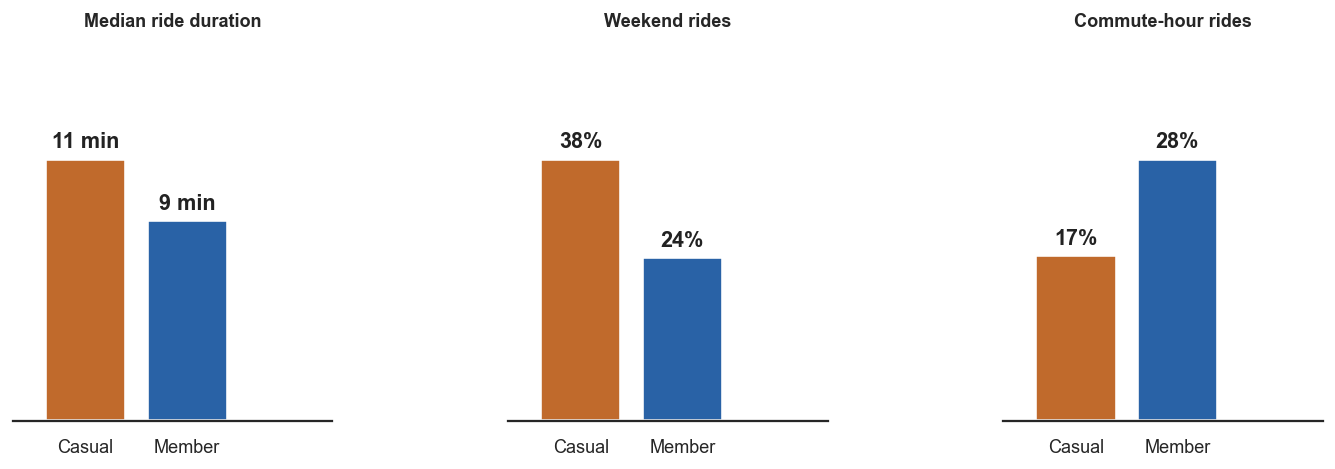

In [9]:
eda_stats = df.groupby('member_casual').agg(
    median_duration = ('trip_duration_min', 'median'),
    weekend_pct     = ('is_weekend',        'mean'),
    commute_pct     = ('is_commute',        'mean'),
).reset_index()

labels = ['Casual', 'Member']
colors = [CASUAL_COLOR, MEMBER_COLOR]
x = np.array([0, 0.35])          # bars close together
bar_w = 0.28                      # narrower bars for clean spacing

specs = [
    ('median_duration', 'Median ride duration', False),
    ('weekend_pct',     'Weekend rides',        True),
    ('commute_pct',     'Commute-hour rides',   True),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.subplots_adjust(wspace=0.55)  # more breathing room between panels

for ax, (col, title, is_pct) in zip(axes, specs):
    vals = eda_stats[col].values
    bar_vals = vals * 100 if is_pct else vals
    ylim_max = max(bar_vals) * 1.45

    bars = ax.bar(x, bar_vals, width=bar_w, color=colors,
                  edgecolor='white', linewidth=2)
    for bar, raw in zip(bars, vals):
        label = f'{raw:.0%}' if is_pct else f'{raw:.0f} min'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ylim_max * 0.03,
                label, ha='center', fontweight='bold',
                fontsize=12, color='#222')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_ylim(0, ylim_max)
    ax.yaxis.set_visible(False)
    ax.xaxis.grid(False)
    ax.set_xlim(-0.25, 0.85)      # tight x-axis around the two bars
    sns.despine(ax=ax, left=True, bottom=False)

plt.savefig(FIG_DIR / 'nb04_eda_key_differences.png', bbox_inches='tight')
plt.show()

The gap is clear. Casual rides last noticeably longer than member rides —
and the median (11 vs 9 minutes) actually understates it, because the casual mean
is pulled much higher by long recreational rides. Members ride in commute windows
notably more often (28% vs 17% of rides), and casual rides skew clearly toward weekends.

These three signals already suggest two structurally different use cases.
The question I want to answer next is whether this holds for *all* casual riders,
or whether some of them actually look quite similar to members once I look more closely.

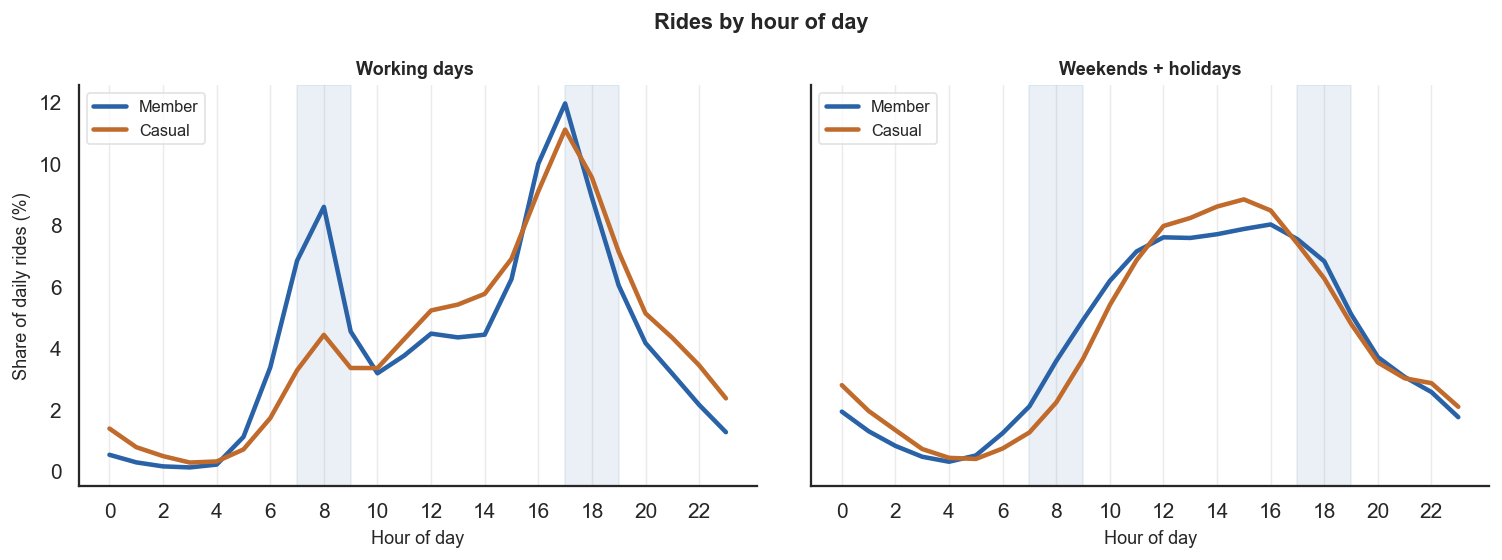

In [10]:
# Rides are counted by departure hour (started_at).
# Each ride contributes +1 to the hour it departs — not spread across its duration.
# Left panel : weekdays that are NOT public holidays
# Right panel: weekends (Sat–Sun) AND public holidays (Illinois calendar)

wd = df[(df['weekday_num'] < 5) & (df['is_holiday'] == 0)]  # true working days
we = df[df['is_nonworking'] == 1]                            # Sat + Sun + holidays

def hourly_pct(subset):
    h = subset.groupby(['member_casual', 'hour']).size().unstack(level=0).fillna(0)
    return h.div(h.sum(axis=0), axis=1) * 100

hourly_wd = hourly_pct(wd)
hourly_we = hourly_pct(we)

# Ride counts for panel subtitles
n_wd = len(wd)
n_we = len(we)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.subplots_adjust(wspace=0.08)

panels = [
    (hourly_wd, f'Working days '),
    (hourly_we, f'Weekends + holidays'),
]
for ax, (hourly, title) in zip(axes, panels):
    ax.plot(hourly.index, hourly['member'], color=MEMBER_COLOR,
            label='Member', linewidth=2.5)
    ax.plot(hourly.index, hourly['casual'], color=CASUAL_COLOR,
            label='Casual', linewidth=2.5)
    ax.axvspan(7,  9,  alpha=0.09, color=MEMBER_COLOR)
    ax.axvspan(17, 19, alpha=0.09, color=MEMBER_COLOR)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
    sns.despine(ax=ax, left=False)

axes[0].set_ylabel('Share of daily rides (%)')
fig.suptitle('Rides by hour of day', fontsize=12, fontweight='bold', y=1.02)

plt.savefig(FIG_DIR / 'nb04_eda_hourly.png', bbox_inches='tight')
plt.show()

On weekdays, the member pattern is unmistakable: two sharp peaks at commuting hours,
a quiet stretch in the middle of the day. The casual curve differs in a specific way:
the morning spike is missing almost entirely, but the late-afternoon peak is there —
nearly as tall as the member one. That PM window mixes genuine commutes with after-work
leisure, so departure time alone can't fully separate the two intents.

On weekends, the two groups converge. Both shift toward midday and afternoon,
and the gap narrows considerably. The cleanest commute discriminator is therefore
the *morning* weekday peak — that's where members stand alone.

> Each ride counts +1 at its departure hour (`started_at`) — departure patterns, not usage minutes.

---
## 4 · Segmentation into Subgroups <a id='clustering'></a>

The aggregate view confirms that casual and member riders are different — but treating
all casual riders as one block is too crude. A frequent evening commuter and a Sunday
tourist are both labelled 'casual', yet they have almost nothing in common.

How many distinct behavioural profiles actually exist within the casual population?
And what do they look like?

I use MiniBatch K-Means on 8 behavioural features to let the data answer this.
K is selected empirically — inertia and silhouette scores are compared across K = 2, 3, 4.

[↑ back to top](#toc)

In [11]:
# ── Isolate casual rides ──────────────────────────────────────────────────────
casual_df = df[df['member_casual'] == 'casual'].copy().reset_index(drop=True)
print(f"Casual rides for clustering: {len(casual_df):,}")

# ── Build feature matrix (cap extreme outliers for cluster stability) ──────────
X_raw = casual_df[CLUSTER_FEATURES].copy()
X_raw['trip_duration_min'] = X_raw['trip_duration_min'].clip(upper=120)
X_raw['distance_km']       = X_raw['distance_km'].clip(upper=15)
X_raw['avg_speed_kmh']     = X_raw['avg_speed_kmh'].clip(upper=40)
X_raw = X_raw.fillna(0)

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"Scaled feature matrix: {X_scaled.shape}")


Casual rides for clustering: 2,094,747
Scaled feature matrix: (2094747, 8)


  K=2 | Inertia=2,054,341 | Silhouette=0.2099


  K=3 | Inertia=1,771,518 | Silhouette=0.1998


  K=4 | Inertia=1,622,527 | Silhouette=0.1593


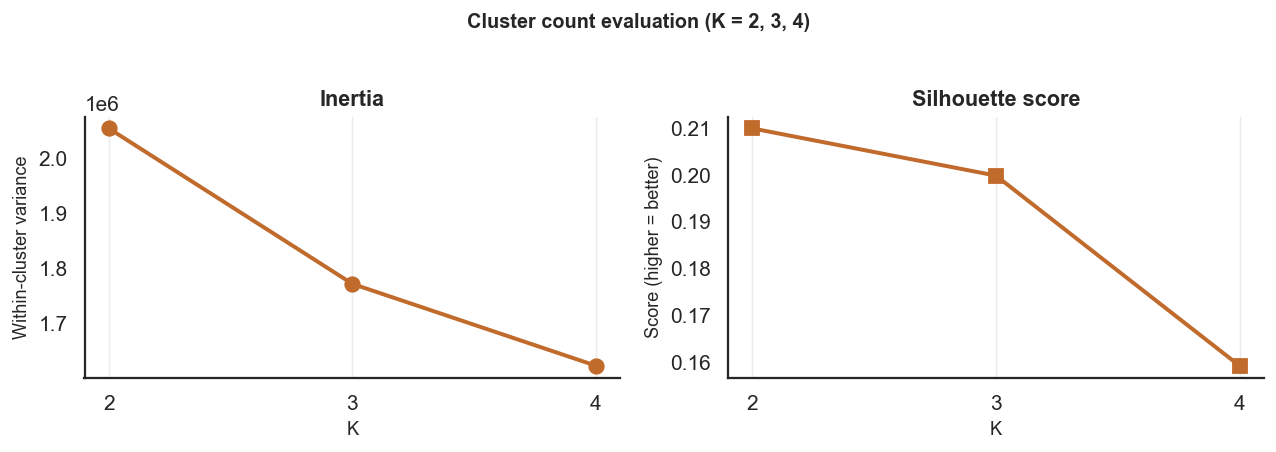

In [12]:
np.random.seed(42)
sample_n   = min(300_000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), size=sample_n, replace=False)
X_sample   = X_scaled[sample_idx]

K_range = [2, 3, 4]
inertias, silhouettes = [], []

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10_000, n_init=5)
    km.fit(X_sample)
    labels_s = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_s, sample_size=30_000, random_state=42)
    inertias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"  K={k} | Inertia={km.inertia_:,.0f} | Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].plot(K_range, inertias, marker='o', color=CASUAL_COLOR,
             linewidth=2.2, markersize=8)
axes[0].set_title('Inertia', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Within-cluster variance')
axes[0].set_xticks(K_range)
sns.despine(ax=axes[0])

axes[1].plot(K_range, silhouettes, marker='s', color=CASUAL_COLOR,
             linewidth=2.2, markersize=8)
axes[1].set_title('Silhouette score', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score (higher = better)')
axes[1].set_xticks(K_range)
sns.despine(ax=axes[1])

plt.suptitle('Cluster count evaluation (K = 2, 3, 4)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_elbow_silhouette.png', bbox_inches='tight')
plt.show()

The inertia curve bends at K=3 — the drop from 2 to 3 clusters is more than twice
the drop from 3 to 4. The silhouette score is technically highest at K=2, but only
by a small margin, and two clusters would just split casual riders into
'weekday vs. weekend' — too coarse to act on.

So I go with K=3: the elbow supports it, the silhouette penalty is marginal,
and three distinct profiles are something a marketing team can actually work with.

One honesty note: both silhouettes are modest in absolute terms, so the clusters
are soft behavioural regions rather than sharply separated groups — I come back
to this in the limitations.

### 4.2 Final Cluster Assignment

With K=3 confirmed, cluster labels are assigned to all casual rides.
The next step is to understand what each cluster actually represents.

In [13]:
K_FINAL = 3   # chosen: meaningful elbow + best interpretability for business

km_final = MiniBatchKMeans(n_clusters=K_FINAL, random_state=42,
                            batch_size=10_000, n_init=10)
km_final.fit(X_sample)                       # fit on representative sample
casual_df['cluster'] = km_final.predict(X_scaled)   # label ALL casual rides

print(f"K={K_FINAL} clusters assigned to {len(casual_df):,} casual rides.")
print("\nRide counts per raw cluster:")
print(casual_df['cluster'].value_counts().sort_index().to_string())


K=3 clusters assigned to 2,094,747 casual rides.

Ride counts per raw cluster:
cluster
0     644221
1    1090948
2     359578


---
## 5 · Subgroup Profiles <a id='profiling'></a>

Three clusters emerged from the data. Now the key question: *what are they?*

Each cluster is automatically named based on its two most dominant behavioural traits,
detected against the thresholds below. The naming follows a fixed hierarchy —
temporal context first, then bike type, then ride style — so names like
"Commute Classic Riders" or "Weekend E-Bike Riders" are directly interpretable.

| Category | Trait | Threshold |
|----------|-------|-----------|
| Temporal | Weekend | weekend share ≥ 65% |
| Temporal | Commute | commute share ≥ 25% AND weekend ≤ 15% |
| Temporal | Weekday | weekend share ≤ 15% (no dominant commute) |
| Bike type | E-Bike | electric share ≥ 70% |
| Bike type | Classic | electric share ≤ 25% |
| Ride style | Leisure | median duration ≥ 18 min |

Fallback name if no threshold is reached: `"Urban Riders"`.

[↑ back to top](#toc)

In [14]:
# ── Aggregate cluster statistics ──────────────────────────────────────────────
profile = casual_df.groupby('cluster').agg(
    rides_count      = ('cluster',          'count'),
    avg_duration_min = ('trip_duration_min', 'median'),
    avg_distance_km  = ('distance_km',       'median'),
    avg_speed_kmh    = ('avg_speed_kmh',     'median'),
    weekend_share    = ('is_weekend',        'mean'),
    peak_hour_share  = ('is_peak_hour',      'mean'),
    commute_share    = ('is_commute',        'mean'),
    electric_share   = ('is_electric',       'mean'),
).reset_index()

# Dominant season per cluster
dom_season = (
    casual_df.groupby('cluster')['season']
    .agg(lambda x: x.value_counts().idxmax())
    .map(SEASON_MAP).reset_index().rename(columns={'season':'dominant_season'})
)
# Dominant time slot per cluster
dom_slot = (
    casual_df.groupby('cluster')['time_slot']
    .agg(lambda x: x.value_counts().idxmax())
    .map(TIME_SLOT_MAP).reset_index().rename(columns={'time_slot':'dominant_slot'})
)
profile = profile.merge(dom_season, on='cluster').merge(dom_slot, on='cluster')

_disp_cols = ['cluster','rides_count','avg_duration_min','avg_distance_km',
              'weekend_share','commute_share','electric_share','dominant_season']
print("Cluster profiles (pre-naming):")
print(profile[_disp_cols].round(3).to_string(index=False))

Cluster profiles (pre-naming):
 cluster  rides_count  avg_duration_min  avg_distance_km  weekend_share  commute_share  electric_share dominant_season
       0       644221            20.413            1.567          0.517          0.006           0.140          Summer
       1      1090948             8.996            1.620          0.419          0.000           0.996          Summer
       2       359578             9.912            1.644          0.000          1.000           0.725          Summer


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  AUTOMATIC SUBGROUP NAMING — multi-trait system
#
#  Each cluster is described by up to 2 dominant behavioral traits.
#  Traits are detected against declared thresholds and scored by intensity.
#  The top 2 traits (highest score, one per category) are combined into a name.
#
#  Trait categories (in semantic name order):
#    temporal  → when they ride  (Weekend / Commute / Weekday)
#    bike_type → what they ride  (E-Bike / Classic)
#    style     → how they ride   (Leisure)
#
#  Thresholds (declared here — change only these to tune the system):
# ══════════════════════════════════════════════════════════════════════════════

THRESHOLDS = {
    'weekend_high':    0.65,   # weekend_share ≥ this → "Weekend"
    'weekend_low':     0.15,   # weekend_share ≤ this → eligible for Weekday/Commute
    'commute_min':     0.25,   # commute_share ≥ this → "Commute" (only if weekday-dominant)
    'electric_high':   0.70,   # electric_share ≥ this → "E-Bike"
    'electric_low':    0.25,   # electric_share ≤ this → "Classic"
    'duration_leisure':18.0,   # avg_duration_min ≥ this → "Leisure"
}

CATEGORY_ORDER = {'temporal': 0, 'bike_type': 1, 'style': 2}


def detect_traits(row: dict, thresholds: dict) -> list:
    """
    Returns a list of (category, label, score) for every triggered trait.
    Score = intensity of the feature (used to select the top 2 most distinctive).
    """
    traits = []
    ws  = row['weekend_share']
    cs  = row['commute_share']
    es  = row['electric_share']
    dur = row['avg_duration_min']

    # ── Temporal ──────────────────────────────────────────────────────────────
    if ws >= thresholds['weekend_high']:
        traits.append(('temporal', 'Weekend', ws))
    elif ws <= thresholds['weekend_low'] and cs >= thresholds['commute_min']:
        traits.append(('temporal', 'Commute', cs))
    elif ws <= thresholds['weekend_low']:
        traits.append(('temporal', 'Weekday', 1 - ws))

    # ── Bike type ─────────────────────────────────────────────────────────────
    if es >= thresholds['electric_high']:
        traits.append(('bike_type', 'E-Bike', es))
    elif es <= thresholds['electric_low']:
        traits.append(('bike_type', 'Classic', 1 - es))

    # ── Ride style ────────────────────────────────────────────────────────────
    if dur >= thresholds['duration_leisure']:
        # Normalise to ~0–1 range for comparability with other scores
        traits.append(('style', 'Leisure', min(dur / 30.0, 1.0)))

    return traits


def auto_name(row, thresholds=THRESHOLDS):
    """
    Builds a subgroup name from the top 2 most distinctive behavioral traits.
    Traits are sorted by score (highest intensity first) and deduplicated
    by category, then reordered semantically for the final name.
    """
    traits = detect_traits(row, thresholds)

    if not traits:
        return 'Urban Riders'   # fallback if no threshold is reached

    # Sort by score descending → take top 2, one per category
    traits.sort(key=lambda t: -t[2])
    seen_cats, selected = set(), []
    for cat, label, score in traits:
        if cat not in seen_cats and len(selected) < 2:
            selected.append((cat, label))
            seen_cats.add(cat)

    # Reorder by semantic category (temporal → bike_type → style)
    selected.sort(key=lambda t: CATEGORY_ORDER[t[0]])
    name_parts = [label for _, label in selected]

    return ' '.join(name_parts) + ' Riders'


profile['subgroup_name'] = profile.apply(auto_name, axis=1)

# Deduplication safeguard (should not trigger with the new system,
# but kept as a safety net in case two clusters produce identical names)
counts = profile['subgroup_name'].value_counts()
for name in counts[counts > 1].index:
    dup_idx = profile[profile['subgroup_name'] == name].index
    for j, idx in enumerate(dup_idx):
        profile.loc[idx, 'subgroup_name'] += f' ({chr(65+j)})'
    print(f"⚠️  Duplicate name detected: '{name}' — review thresholds in THRESHOLDS dict")

# Semantic color (keyword-based — see subgroup_color() in imports)
profile['color'] = profile['subgroup_name'].apply(subgroup_color)
name_to_color = dict(zip(profile['subgroup_name'], profile['color']))

casual_df['subgroup_name'] = casual_df['cluster'].map(
    profile.set_index('cluster')['subgroup_name']
)

# ── Summary ───────────────────────────────────────────────────────────────────
print('Cluster → Subgroup name (multi-trait system)')
print('─' * 60)
for _, row in profile.iterrows():
    traits_detail = detect_traits(row, THRESHOLDS)
    traits_detail.sort(key=lambda t: -t[2])
    trait_str = ' | '.join(f'{l} ({s:.2f})' for _, l, s in traits_detail)
    print(f"  Cluster {row['cluster']}  →  {row['subgroup_name']}")
    print(f"    traits  : {trait_str}")
    print(f"    weekend : {row['weekend_share']*100:.0f}%  "
          f"commute: {row['commute_share']*100:.0f}%  "
          f"electric: {row['electric_share']*100:.0f}%  "
          f"duration: {row['avg_duration_min']:.1f} min")
    print()


Cluster → Subgroup name (multi-trait system)
────────────────────────────────────────────────────────────
  Cluster 0  →  Classic Leisure Riders
    traits  : Classic (0.86) | Leisure (0.68)
    weekend : 52%  commute: 1%  electric: 14%  duration: 20.4 min

  Cluster 1  →  E-Bike Riders
    traits  : E-Bike (1.00)
    weekend : 42%  commute: 0%  electric: 100%  duration: 9.0 min

  Cluster 2  →  Commute E-Bike Riders
    traits  : Commute (1.00) | E-Bike (0.73)
    weekend : 0%  commute: 100%  electric: 73%  duration: 9.9 min



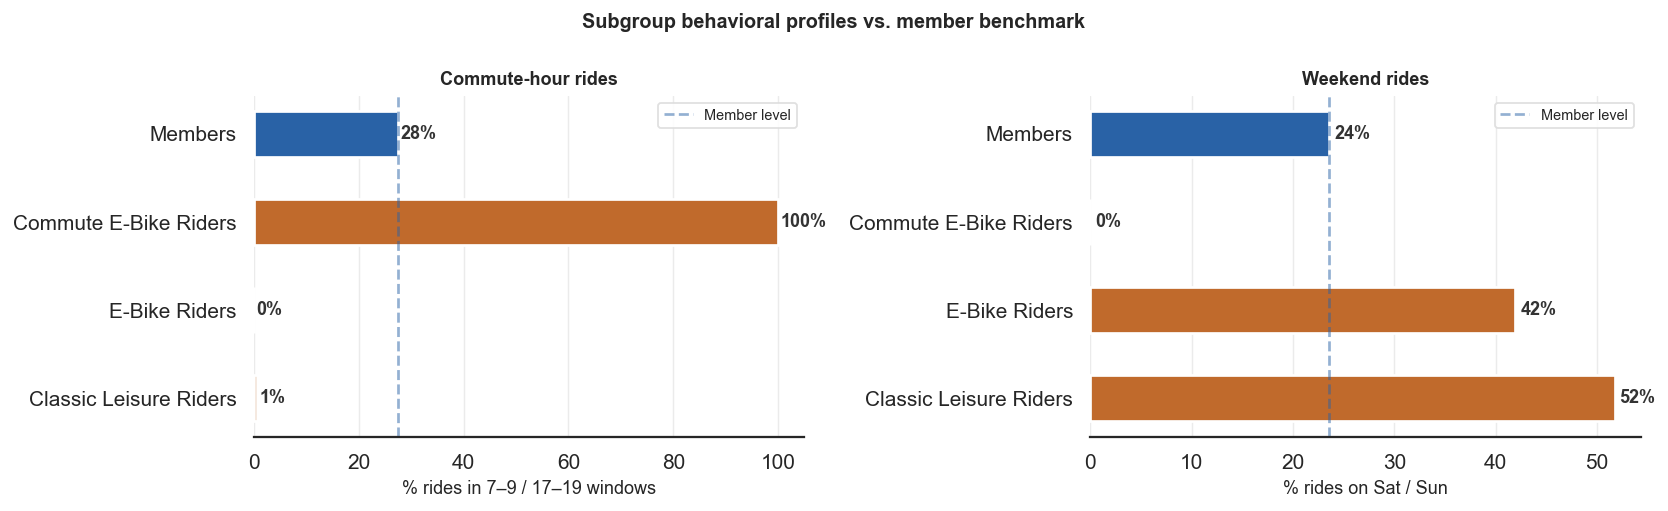

In [16]:
member_bench = df[df['member_casual'] == 'member'].agg({
    'trip_duration_min': 'median',
    'distance_km':       'median',
    'avg_speed_kmh':     'median',
    'is_weekend':        'mean',
    'is_commute':        'mean',
    'is_electric':       'mean',
}).rename({
    'trip_duration_min': 'avg_duration_min',
    'distance_km':       'avg_distance_km',
    'is_weekend':        'weekend_share',
    'is_commute':        'commute_share',
    'is_electric':       'electric_share',
})

BENCH_FEATURES = ['avg_duration_min', 'avg_distance_km', 'avg_speed_kmh',
                  'weekend_share', 'commute_share', 'electric_share']

cluster_vals = profile.set_index('subgroup_name')[BENCH_FEATURES]
member_row   = pd.DataFrame([member_bench[BENCH_FEATURES].values],
                             columns=BENCH_FEATURES, index=['Members'])
all_rows     = pd.concat([cluster_vals, member_row])

all_names  = list(profile['subgroup_name']) + ['Members']
all_colors = [CASUAL_COLOR] * len(profile) + [MEMBER_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Subgroup behavioral profiles vs. member benchmark',
             fontsize=11, fontweight='bold')

for ax, (col, xlabel) in zip(axes, [
    ('commute_share', '% rides in 7–9 / 17–19 windows'),
    ('weekend_share', '% rides on Sat / Sun'),
]):
    vals = all_rows[col].values * 100
    bars = ax.barh(all_names, vals, color=all_colors,
                   edgecolor='white', linewidth=1.5, height=0.52)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{v:.0f}%', va='center', fontweight='bold',
                fontsize=10, color='#333')
    ref = member_bench[col] * 100
    ax.axvline(ref, color=MEMBER_COLOR, linestyle='--',
               linewidth=1.5, alpha=0.5, label='Member level')
    title = 'Commute-hour rides' if col == 'commute_share' else 'Weekend rides'
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)
    sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_subgroup_profiles.png', bbox_inches='tight')
plt.show()

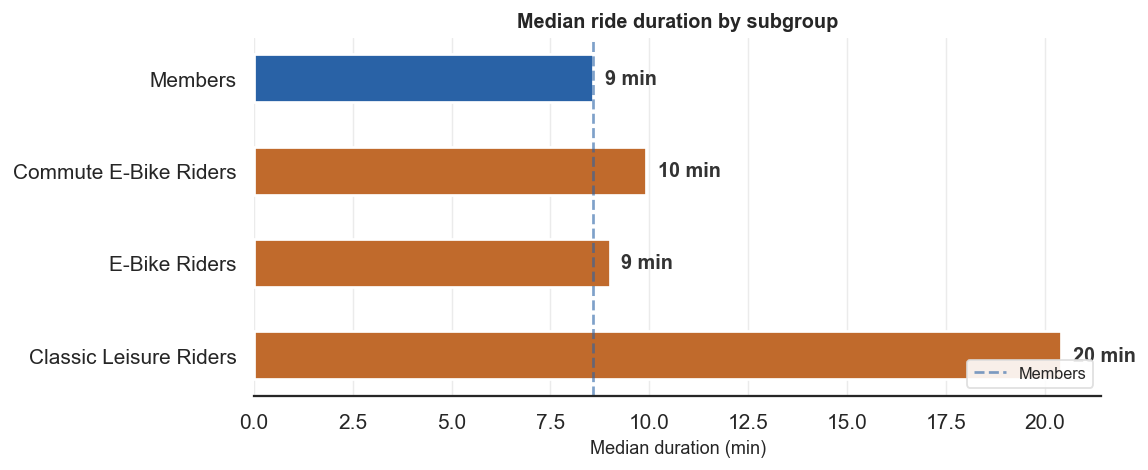

In [17]:
dur_vals  = all_rows['avg_duration_min'].values
dur_names = list(all_names)

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(dur_names, dur_vals, color=all_colors,
               edgecolor='white', linewidth=1.5, height=0.52)
for bar, v in zip(bars, dur_vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{v:.0f} min', va='center', fontweight='bold',
            fontsize=11, color='#333')

ax.axvline(member_bench['avg_duration_min'], color=MEMBER_COLOR,
           linestyle='--', linewidth=1.5, alpha=0.6, label='Members')
ax.set_title('Median ride duration by subgroup', fontweight='bold', fontsize=11)
ax.set_xlabel('Median duration (min)')
ax.legend(loc='lower right', fontsize=9)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_duration_by_subgroup.png', bbox_inches='tight')
plt.show()

Most casual subgroups ride longer than members — but not all of them.
The commute-pattern subgroup sits essentially on the member benchmark,
while the leisure-oriented one is more than twice as far from it.

Short, purposeful trips are a member hallmark, so a casual subgroup that already
matches that brevity is structurally more compatible with a membership model.

---
### Are Members Homogeneous? <a id='members_homo'></a>

Before using 'member behaviour' as a fixed reference point, I want to check:
are members actually a uniform group, or do different member types exist?
If the benchmark itself is fragmented, comparisons become less meaningful.

The same clustering is run on member rides to check.

[↑ back to top](#toc)

In [18]:
# ── Member clustering ─────────────────────────────────────────────────────────
member_df = df[df['member_casual'] == 'member'].copy().reset_index(drop=True)
print(f"Member rides: {len(member_df):,}")

X_mem_raw = member_df[CLUSTER_FEATURES].copy()
X_mem_raw['trip_duration_min'] = X_mem_raw['trip_duration_min'].clip(upper=120)
X_mem_raw['distance_km']       = X_mem_raw['distance_km'].clip(upper=15)
X_mem_raw['avg_speed_kmh']     = X_mem_raw['avg_speed_kmh'].clip(upper=40)
X_mem_raw = X_mem_raw.fillna(0)

scaler_mem  = StandardScaler()
X_mem_scaled = scaler_mem.fit_transform(X_mem_raw)

# Choose K by silhouette on a 200k sample
np.random.seed(42)
mem_sample_idx = np.random.choice(len(X_mem_scaled), size=min(200_000, len(X_mem_scaled)), replace=False)
X_mem_sample   = X_mem_scaled[mem_sample_idx]

best_k_mem, best_sil_mem = 2, -1
for k in [2, 3]:
    km_tmp = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10_000, n_init=5)
    km_tmp.fit(X_mem_sample)
    sil = silhouette_score(X_mem_sample, km_tmp.predict(X_mem_sample),
                           sample_size=30_000, random_state=42)
    print(f"  Member K={k} | Silhouette={sil:.4f}")
    if sil > best_sil_mem:
        best_sil_mem, best_k_mem = sil, k

print(f"\nSelected K={best_k_mem} for member segmentation (best silhouette).")
km_mem = MiniBatchKMeans(n_clusters=best_k_mem, random_state=42, batch_size=10_000, n_init=10)
km_mem.fit(X_mem_sample)
member_df['cluster'] = km_mem.predict(X_mem_scaled)
print(f"Member cluster sizes:\n{member_df['cluster'].value_counts().sort_index().to_string()}")

Member rides: 3,746,984


  Member K=2 | Silhouette=0.1439


  Member K=3 | Silhouette=0.1652

Selected K=3 for member segmentation (best silhouette).
Member cluster sizes:
cluster
0    1030962
1     883531
2    1832491


In [19]:
mem_profile = member_df.groupby('cluster').agg(
    rides_count      = ('cluster',          'count'),
    avg_duration_min = ('trip_duration_min', 'median'),
    avg_distance_km  = ('distance_km',       'median'),
    avg_speed_kmh    = ('avg_speed_kmh',     'median'),
    weekend_share    = ('is_weekend',        'mean'),
    commute_share    = ('is_commute',        'mean'),
    electric_share   = ('is_electric',       'mean'),
).reset_index()

mem_dom_season = (
    member_df.groupby('cluster')['season']
    .agg(lambda x: x.value_counts().idxmax())
    .map(SEASON_MAP).reset_index().rename(columns={'season': 'dominant_season'})
)
mem_profile = mem_profile.merge(mem_dom_season, on='cluster')
mem_profile['share_of_member'] = mem_profile['rides_count'] / len(member_df) * 100

# ══════════════════════════════════════════════════════════════════════════════
#  MEMBER NAMING — same multi-trait logic as casual, member-calibrated thresholds
#
#  Key difference from casual thresholds:
#    - Weekend share is uniform across member clusters (~22–27%) → not discriminating
#    - Commute triggers only when commute_share >= 0.25 AND duration < 12 min
#      (short purposeful trips = commute behavior; long trips with same commute %
#       are more likely cross-city or recreational, not classic commuting)
#    - Long-Distance added as a style trait for members (dist >= 4 km)
# ══════════════════════════════════════════════════════════════════════════════

MEMBER_THRESHOLDS = {
    'weekend_high':       0.45,   # weekend_share >= → Weekend  (high bar: members are regular)
    'commute_min':        0.25,   # commute_share >= AND dur < commute_dur_max → Commute
    'commute_dur_max':    12.0,   # max duration (min) for a ride to count as commute-pattern
    'electric_high':      0.65,   # electric_share >= → E-Bike (lower bar than casual: 68% qualifies)
    'electric_low':       0.25,   # electric_share <= → Classic
    'duration_leisure':   18.0,   # avg_duration_min >= → Leisure
    'distance_long':       4.0,   # avg_distance_km >= → Long-Distance
}


def detect_member_traits(row: dict, th: dict) -> list:
    """
    Returns (category, label, score) for every triggered member trait.
    Uses member-calibrated thresholds.
    """
    traits = []
    ws  = row['weekend_share']
    cs  = row['commute_share']
    es  = row['electric_share']
    dur = row['avg_duration_min']
    dist= row['avg_distance_km']

    # ── Temporal ──────────────────────────────────────────────────────────────
    # Weekend: only very strong weekend signal (members are generally regular)
    if ws >= th['weekend_high']:
        traits.append(('temporal', 'Weekend', ws))
    # Commute: high commute share + SHORT trip → purposeful commuting behavior
    # (Long trips with similar commute share are cross-city, not typical commuting)
    elif cs >= th['commute_min'] and dur < th['commute_dur_max']:
        traits.append(('temporal', 'Commute', cs))

    # ── Bike type ─────────────────────────────────────────────────────────────
    if es >= th['electric_high']:
        traits.append(('bike_type', 'E-Bike', es))
    elif es <= th['electric_low']:
        traits.append(('bike_type', 'Classic', 1 - es))

    # ── Ride style ────────────────────────────────────────────────────────────
    # Long-Distance: member-specific trait (cross-city rides, longer commutes)
    if dist >= th['distance_long']:
        traits.append(('style', 'Long-Distance', min(dist / 10.0, 1.0)))
    # Leisure: long duration (even without long distance)
    elif dur >= th['duration_leisure']:
        traits.append(('style', 'Leisure', min(dur / 30.0, 1.0)))

    return traits


def auto_name_member(row, th=MEMBER_THRESHOLDS):
    """
    Builds a member subgroup name from the top 2 most distinctive traits.
    Same algorithm as casual auto_name() — different thresholds only.
    """
    traits = detect_member_traits(row, th)

    if not traits:
        return 'Regular Riders'  # fallback for member clusters with no strong signal

    traits.sort(key=lambda t: -t[2])
    seen_cats, selected = set(), []
    for cat, label, score in traits:
        if cat not in seen_cats and len(selected) < 2:
            selected.append((cat, label))
            seen_cats.add(cat)

    selected.sort(key=lambda t: CATEGORY_ORDER[t[0]])
    return ' '.join(label for _, label in selected) + ' Members'


mem_profile['subgroup_name'] = mem_profile.apply(auto_name_member, axis=1)

# Deduplication safeguard
mem_counts = mem_profile['subgroup_name'].value_counts()
for name in mem_counts[mem_counts > 1].index:
    dup_idx = mem_profile[mem_profile['subgroup_name'] == name].index
    for j, idx in enumerate(dup_idx):
        mem_profile.loc[idx, 'subgroup_name'] += f' ({chr(65+j)})'
    print(f"⚠️  Duplicate member name: '{name}' — review MEMBER_THRESHOLDS")

mem_profile['color'] = MEMBER_SUBGROUP_COLORS[:len(mem_profile)]
member_df['subgroup_name'] = member_df['cluster'].map(
    mem_profile.set_index('cluster')['subgroup_name']
)

# ── Summary ───────────────────────────────────────────────────────────────────
print('Member subgroup names (multi-trait system)')
print('─' * 60)
for _, row in mem_profile.iterrows():
    traits_detail = detect_member_traits(row, MEMBER_THRESHOLDS)
    traits_detail.sort(key=lambda t: -t[2])
    trait_str = ' | '.join(f'{l} ({s:.2f})' for _, l, s in traits_detail)
    print(f"  Cluster {row['cluster']}  →  {row['subgroup_name']}")
    print(f"    traits  : {trait_str if trait_str else '(none — fallback)'}")
    print(f"    weekend : {row['weekend_share']*100:.0f}%  "
          f"commute: {row['commute_share']*100:.0f}%  "
          f"electric: {row['electric_share']*100:.0f}%  "
          f"duration: {row['avg_duration_min']:.1f} min  "
          f"distance: {row['avg_distance_km']:.2f} km")
    print()

Member subgroup names (multi-trait system)
────────────────────────────────────────────────────────────
  Cluster 0  →  Commute E-Bike Members
    traits  : Commute (1.00) | E-Bike (0.65)
    weekend : 0%  commute: 100%  electric: 65%  duration: 8.9 min  distance: 1.71 km

  Cluster 1  →  Weekend E-Bike Members
    traits  : Weekend (1.00) | E-Bike (0.65)
    weekend : 100%  commute: 0%  electric: 65%  duration: 9.2 min  distance: 1.68 km

  Cluster 2  →  E-Bike Members
    traits  : E-Bike (0.66)
    weekend : 0%  commute: 0%  electric: 66%  duration: 8.2 min  distance: 1.54 km



The member side is not monolithic either — but the structure is reassuring:
the weekday member subgroups still out-commute even the most commute-oriented
casual subgroup, and the largest of them does it with shorter, more purposeful trips.
The gap is real, just narrower than the casual average suggests.

This tells me that closing it requires more than a promotional message;
it requires reaching casual riders who already use the service in a
way that resembles membership, and nudging them over the line.

---
### All Subgroups at a Glance <a id='all_subgroups'></a>

With 3 casual and 2–3 member subgroups on the board, it helps to see everything
side by side. Which casual subgroup is closest to which member subgroup across
duration, commute share, weekend share, and electric usage?

The table below makes that comparison immediate.

[↑ back to top](#toc)

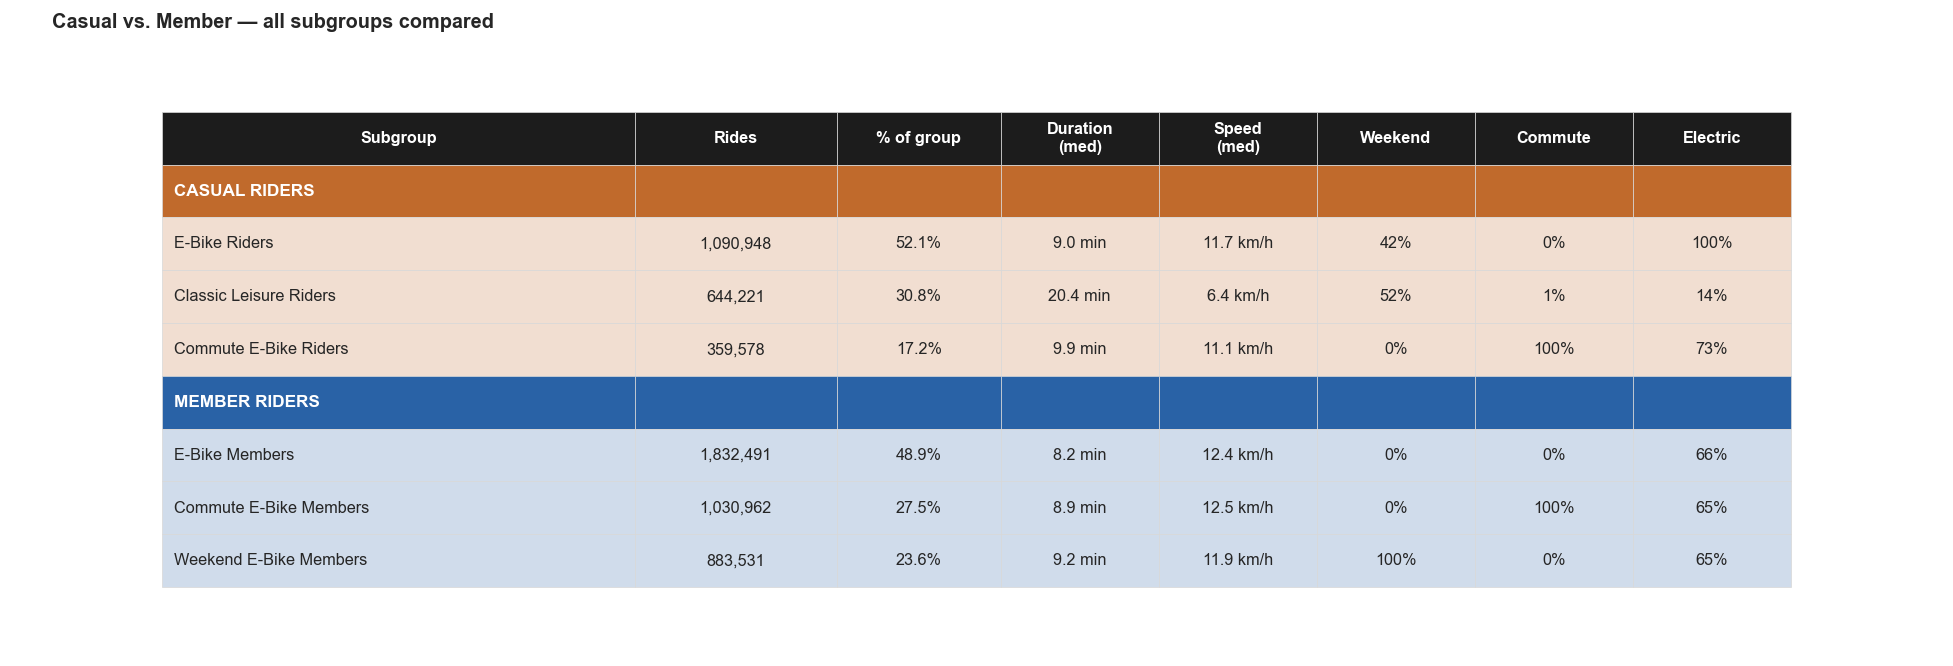

In [20]:
# Ensure share columns exist (also computed in §6.2 — guarded so this cell runs standalone)
if 'share_of_casual' not in profile.columns:
    profile['share_of_casual'] = profile['rides_count'] / len(casual_df) * 100
    profile['share_of_total']  = profile['rides_count'] / len(df)       * 100

import matplotlib.colors as mc

# -- Color helper --
def lighten(hex_col, alpha=0.22):
    r, g, b = mc.to_rgb(hex_col)
    return (1 - alpha*(1-r), 1 - alpha*(1-g), 1 - alpha*(1-b))

# -- Build data rows --
def make_rows(prof, share_col, base_color):
    rows, row_colors = [], []
    for _, r in prof.sort_values('rides_count', ascending=False).iterrows():
        rows.append([
            r['subgroup_name'],
            f"{r['rides_count']:,}",
            f"{r[share_col]:.1f}%",
            f"{r['avg_duration_min']:.1f} min",
            f"{r['avg_speed_kmh']:.1f} km/h",
            f"{r['weekend_share']*100:.0f}%",
            f"{r['commute_share']*100:.0f}%",
            f"{r['electric_share']*100:.0f}%",
        ])
        row_colors.append([lighten(base_color)] * 8)
    return rows, row_colors

c_rows, c_colors = make_rows(profile, 'share_of_casual', CASUAL_COLOR)
m_rows, m_colors = make_rows(mem_profile, 'share_of_member', MEMBER_COLOR)

# -- Section separator rows --
EMPTY  = [''] * 8
c_sep  = ['CASUAL RIDERS'] + EMPTY[1:]
m_sep  = ['MEMBER RIDERS'] + EMPTY[1:]

all_rows   = [c_sep] + c_rows + [m_sep] + m_rows
all_colors = ([[lighten(CASUAL_COLOR, 0.75)] * 8] + c_colors +
              [[lighten(MEMBER_COLOR, 0.75)] * 8] + m_colors)

# -- Column labels --
COL_LABELS = ['Subgroup', 'Rides', '% of group',
              'Duration\n(med)', 'Speed\n(med)',
              'Weekend', 'Commute', 'Electric']
N_COLS = len(COL_LABELS)

# -- Draw --
n_rows = len(all_rows)
fig_h  = 0.6 + n_rows * 0.50 + 0.5

fig, ax = plt.subplots(figsize=(15, fig_h))
ax.axis('off')

tbl = ax.table(
    cellText=all_rows,
    colLabels=COL_LABELS,
    cellColours=all_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.05)

# Column header row (row index 0 in tbl)
for j in range(N_COLS):
    cell = tbl[0, j]
    cell.set_facecolor('#1C1C1C')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)
    cell.set_edgecolor('#1C1C1C')

# Section separator rows
c_sep_tbl = 1
m_sep_tbl = 1 + len(c_rows) + 1

for j in range(N_COLS):
    tbl[c_sep_tbl, j].set_facecolor(CASUAL_COLOR)
    tbl[c_sep_tbl, j].set_text_props(color='white', fontweight='bold', fontsize=9.5)
    tbl[c_sep_tbl, j].set_edgecolor(CASUAL_COLOR)
    tbl[m_sep_tbl, j].set_facecolor(MEMBER_COLOR)
    tbl[m_sep_tbl, j].set_text_props(color='white', fontweight='bold', fontsize=9.5)
    tbl[m_sep_tbl, j].set_edgecolor(MEMBER_COLOR)

# Cell styling: borders + left-align subgroup column
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_linewidth(0.4)
    cell.set_edgecolor('#D8D8D8')
    if col_i == 0 and row_i > 0:
        cell.set_text_props(ha='left')
        cell.PAD = 0.025

# Column widths
col_widths = [0.245, 0.105, 0.085, 0.082, 0.082, 0.082, 0.082, 0.082]
for (row_i, col_i), cell in tbl.get_celld().items():
    if 0 <= col_i < len(col_widths):
        cell.set_width(col_widths[col_i])

ax.set_title('Casual vs. Member — all subgroups compared',
             fontsize=11, fontweight='bold', pad=10, loc='left', x=0.02)

plt.tight_layout(pad=0.5)
plt.savefig(FIG_DIR / 'nb04_subgroup_comparison_table.png',
            bbox_inches='tight', dpi=150)
plt.show()


---
## 6 · Similarity, Volume & Conversion Priority <a id='similarity'></a>

### 6.1 How Close Are the Casual Subgroups to Member Behaviour? <a id='sim_score'></a>

The profiles in Section 5 give a qualitative sense of which subgroup looks most
like a member. Here I formalise that: each casual subgroup is scored against
the overall member profile using Euclidean distance in standardised feature space.

The score runs from 0 (furthest) to 1 (closest). It's a relative ranking —
1.0 means most similar *within this set*, not identical to the member profile.

[↑ back to top](#toc)

In [21]:
SIM_FEATURES = ['avg_duration_min', 'avg_distance_km', 'avg_speed_kmh',
                'weekend_share', 'commute_share', 'electric_share']

# ── Build combined profile table (clusters + member) ─────────────────────────
cluster_centroids = profile.set_index('subgroup_name')[SIM_FEATURES].copy()
member_centroid   = pd.DataFrame(
    [member_bench[SIM_FEATURES].values],
    columns=SIM_FEATURES, index=['Member']
)
all_centroids = pd.concat([cluster_centroids, member_centroid])

# ── Scale and compute Euclidean distance in standardised feature space ────────
scaler_sim  = StandardScaler()
all_scaled  = pd.DataFrame(
    scaler_sim.fit_transform(all_centroids),
    index=all_centroids.index, columns=SIM_FEATURES
)

member_vec     = all_scaled.loc['Member'].values
cluster_scaled = all_scaled.drop('Member')
distances      = np.linalg.norm(cluster_scaled.values - member_vec, axis=1)
max_dist       = distances.max() if distances.max() > 0 else 1.0
sim_scores     = (1 - distances / max_dist).round(4)

profile['similarity_to_member'] = sim_scores

_sim_tbl = pd.DataFrame({
    'Subgroup':   list(profile['subgroup_name']),
    'Similarity': sim_scores.round(3),
    'Distance':   distances.round(3),
}).sort_values('Similarity', ascending=False).reset_index(drop=True)
_sim_tbl.index += 1
print("Similarity to member profile (ranked):")
print(_sim_tbl.to_string())
print("Note: score is relative — 1.0 = most similar in this set.")

Similarity to member profile (ranked):
                 Subgroup  Similarity  Distance
1           E-Bike Riders       0.650     1.611
2   Commute E-Bike Riders       0.486     2.368
3  Classic Leisure Riders       0.000     4.610
Note: score is relative — 1.0 = most similar in this set.


The ranking shows a clear spread — the three casual subgroups are not at
equal distance from member behaviour. One subgroup sits meaningfully closer
than the others, while one sits clearly further away.

Given that each centroid summarises hundreds of thousands of rides, this spread
isn't noise: it's a structural difference with direct implications for where
conversion effort is worth concentrating. One caveat — the ranking depends on
the six features I chose to compare on; a different feature set could reorder
the middle of the ranking.

---
### 6.2 How Many Rides Does Each Subgroup Generate? <a id='volume'></a>

Similarity is only half the story. A subgroup that looks like a member
but represents just 5% of casual rides is a limited opportunity.
Before ranking, I need to know the scale of each group.

> One bias to keep in mind: these are shares of **rides**, not of **people**.
> Frequent riders are over-represented, and a commute-like subgroup almost
> certainly contains the most frequent riders — so its share of distinct
> *users* is likely smaller than its share of rides.

[↑ back to top](#toc)

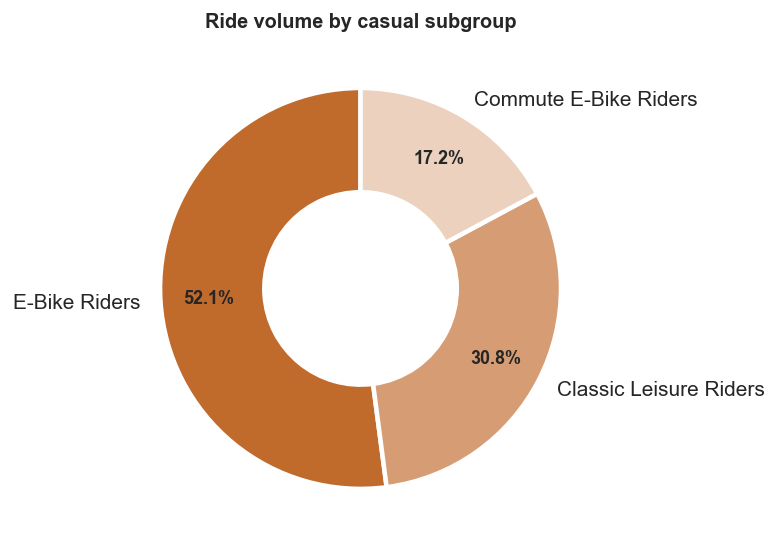

In [22]:
import matplotlib.colors as mcolors

n_total  = len(df)
n_casual = len(casual_df)
profile['share_of_casual'] = profile['rides_count'] / n_casual * 100
profile['share_of_total']  = profile['rides_count'] / n_total  * 100
sorted_w = profile.sort_values('rides_count', ascending=False)

n = len(sorted_w)
base = mcolors.to_rgb(CASUAL_COLOR)
shades = [
    mcolors.to_hex([min(1, c + (1 - c) * i / (n - 0.1)) for c in base])
    for i in range(n)
]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    sorted_w['rides_count'],
    labels=sorted_w['subgroup_name'],
    autopct='%1.1f%%',
    colors=shades,
    pctdistance=0.76,
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5)
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(10)
ax.set_title('Ride volume by casual subgroup', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_business_weight.png', bbox_inches='tight')
plt.show()

What I'm looking for here: is the largest subgroup also the most member-like,
or is there a trade-off between scale and similarity?
That tension is exactly what the priority score in the next section resolves.

---
### 6.3 Conversion Priority <a id='priority'></a>

Now I combine the two dimensions — similarity and ride volume — into a single
priority score:

**Combined score = similarity × ride share**

A high score means the subgroup both *looks like a member* and *represents
a meaningful share of casual rides* — the strongest structural conversion target.
The marketing priority (High / Medium / Low) follows directly from the ranking
on this score. Since ride share inherits the rides-vs-people bias from §6.2,
I read the score as prioritising *observed behaviour*, not audience headcount.

[↑ back to top](#toc)

In [23]:
profile['combined_score'] = (profile['similarity_to_member'] *
                             profile['share_of_casual'] / 100).round(4)

# Priority follows the ranking on the combined score. With only 3 subgroups a
# median-split quadrant is degenerate (each median value passes its own
# threshold), so a straight ranking is the honest choice.
rank  = profile['combined_score'].rank(ascending=False, method='first')
n_sub = len(profile)
profile['marketing_priority'] = rank.map(
    lambda r: 'High' if r == 1 else ('Low' if r == n_sub else 'Medium')
)

_prio_tbl = profile[['subgroup_name','marketing_priority','similarity_to_member',
                      'share_of_casual','combined_score']]\
    .sort_values('combined_score', ascending=False)\
    .rename(columns={'subgroup_name':'Subgroup','marketing_priority':'Priority',
                     'similarity_to_member':'Similarity','share_of_casual':'Ride share %',
                     'combined_score':'Combined score'})
print("Conversion priority ranking:")
print(_prio_tbl.round(3).to_string(index=False))

Conversion priority ranking:
              Subgroup Priority  Similarity  Ride share %  Combined score
         E-Bike Riders     High       0.650        52.080           0.339
 Commute E-Bike Riders   Medium       0.486        17.166           0.084
Classic Leisure Riders      Low       0.000        30.754           0.000


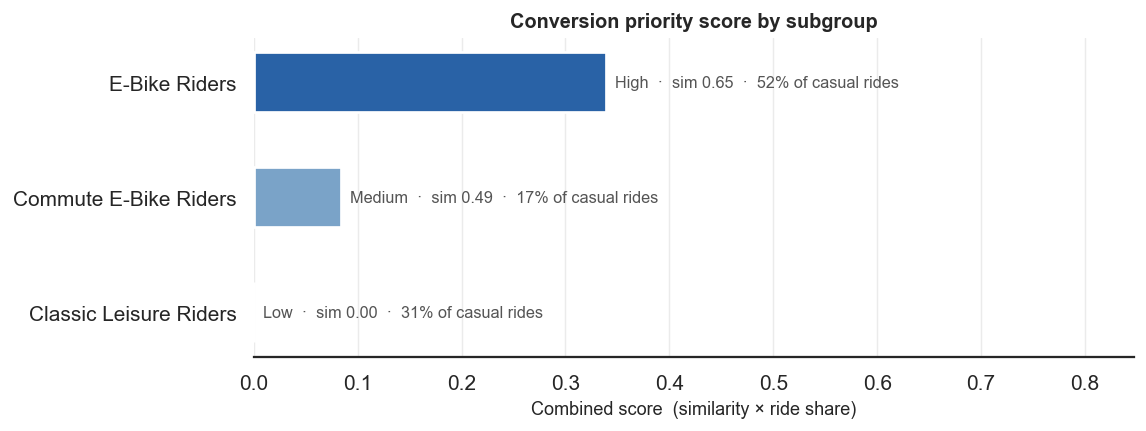

In [24]:
priority_sorted = profile.sort_values('combined_score', ascending=True)


fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(
    priority_sorted['subgroup_name'],
    priority_sorted['combined_score'],
    color=[PRIORITY_COLORS[p] for p in priority_sorted['marketing_priority']],
    edgecolor='white', linewidth=1.5, height=0.52
)
for bar, (_, row) in zip(bars, priority_sorted.iterrows()):
    ax.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"  {row['marketing_priority']}  ·  sim {row['similarity_to_member']:.2f}  ·  {row['share_of_casual']:.0f}% of casual rides",
        va='center', fontsize=9, color='#555'
    )
ax.set_xlabel('Combined score  (similarity × ride share)')
ax.set_title('Conversion priority score by subgroup', fontweight='bold', fontsize=11)
ax.set_xlim(0, priority_sorted['combined_score'].max() * 2.5)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_priority_ranking.png', bbox_inches='tight')
plt.show()

One subgroup pulls clearly ahead on the combined score — driven by a combination
of meaningful similarity to members and sufficient ride volume.
The others trail, not because they're irrelevant, but because the trade-off
between similarity and scale is less favourable.

This is the starting point for a conversion campaign:
focus resources on the high-combined-score group, explore alternative products for the rest.

---
### E-Bike Usage Among PM Casual Commuters <a id='ebike_pm'></a>

One subgroup emerged as behaviourally close to members — but there's a more specific
question worth asking about the commute-adjacent casual riders:
when they head home in the evening, do they prefer e-bikes?
And do those rides end outside docking stations — which could signal an
infrastructure gap, or simply the convenience of free-floating parking?

If both answers are yes, there's a concrete lever here beyond marketing alone.

[↑ back to top](#toc)

PM casual commuters : 253,988 rides (12.1% of casual)
E-bike share        : 70.4%  vs  68.6% (all casual)
Ends outside dock   : 26.9%  vs  24.7% (all casual)


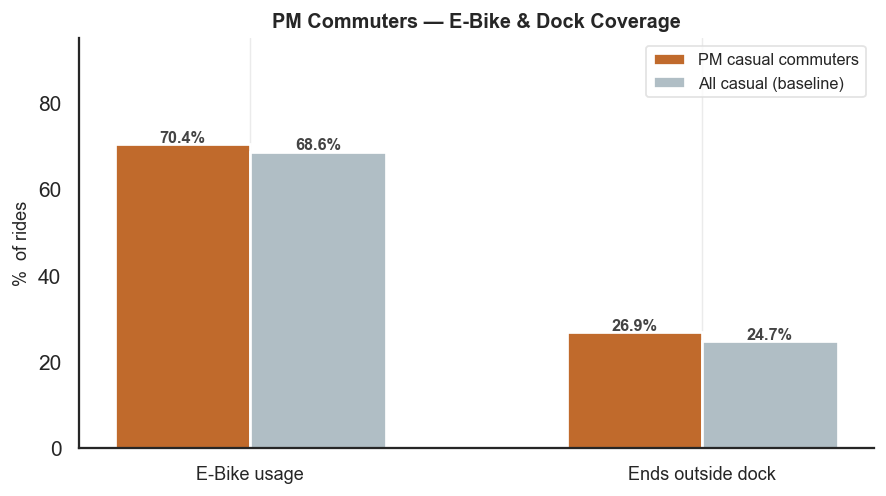

In [25]:
# PM casual commuters: weekday, departure 17:00–18:59, non-holiday
pm_commuters = casual_df[
    (casual_df['is_commute']   == 1) &
    (casual_df['hour']         >= COMMUTE_PM[0]) &
    (casual_df['hour']          < COMMUTE_PM[1]) &
    (casual_df['is_holiday']   == 0)
].copy()

# Metrics for PM commuters vs all casual (baseline)
ebike_pm    = pm_commuters['is_electric'].mean()       * 100
ebike_all   = casual_df['is_electric'].mean()          * 100
nodock_pm   = pm_commuters['end_station_name'].isnull().mean() * 100
nodock_all  = casual_df['end_station_name'].isnull().mean()    * 100

print(f"PM casual commuters : {len(pm_commuters):,} rides ({len(pm_commuters)/len(casual_df)*100:.1f}% of casual)")
print(f"E-bike share        : {ebike_pm:.1f}%  vs  {ebike_all:.1f}% (all casual)")
print(f"Ends outside dock   : {nodock_pm:.1f}%  vs  {nodock_all:.1f}% (all casual)")

# Chart: two grouped bars (PM commuters vs all casual) for each metric
labels   = ['E-Bike usage', 'Ends outside dock']
vals_pm  = [ebike_pm,  nodock_pm]
vals_all = [ebike_all, nodock_all]

x     = np.array([0.0, 1.0])
w     = 0.30
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, vals_pm,  width=w, color=CASUAL_COLOR,     label='PM casual commuters',
            edgecolor='white', linewidth=1.5)
b2 = ax.bar(x + w/2, vals_all, width=w, color='#B0BEC5', label='All casual (baseline)',
            edgecolor='white', linewidth=1.5)

for bar, v in zip(list(b1) + list(b2), vals_pm + vals_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color='#444')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('%  of rides')
ax.set_title('PM Commuters — E-Bike & Dock Coverage', fontweight='bold', fontsize=11)
ax.set_ylim(0, max(vals_pm + vals_all) * 1.35)
ax.legend(fontsize=9, framealpha=0.8)
sns.despine(ax=ax, left=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_pm_commuters_ebike_dock.png', bbox_inches='tight')
plt.show()

The honest reading: the differences vs. the casual average are modest — a couple
of percentage points on both metrics. What matters here is the absolute level:
roughly 7 out of 10 PM commute rides happen on an e-bike, and about 1 in 4 ends
outside a docking station.

The dock coverage gap matters because it creates a morning problem — a rider
who parks free-floating in the evening has no guarantee of finding a bike near
home the next morning. Expanding docking infrastructure in the residential areas
where these PM rides end could remove a real conversion barrier.

> Two caveats: 'ends outside dock' can only happen on e-bikes, so the two metrics
> are partly linked. And without coordinate-level spatial analysis I can't say
> *which specific areas* to prioritise — that would require geographic clustering
> of the no-dock endpoints.

---
## 7 · Per-Subgroup Breakdown <a id='insights'></a>

The aggregate scores are useful, but each subgroup has its own story.
Below, each one is profiled in detail: what it looks like behaviourally,
what that implies for conversion potential, and what marketing approach might work.

The summary table and the four key questions at the end collect the most actionable
numbers in one place.

[↑ back to top](#toc)

In [26]:
summary = profile[[
    'subgroup_name', 'rides_count', 'share_of_casual', 'share_of_total',
    'avg_duration_min', 'avg_distance_km', 'avg_speed_kmh',
    'weekend_share', 'commute_share', 'peak_hour_share', 'dominant_season',
    'similarity_to_member', 'combined_score', 'marketing_priority'
]].copy()

summary.columns = [
    'casual_subgroup', 'rides_count', 'share_of_casual_rides_%',
    'share_of_total_rides_%', 'avg_ride_duration_min',
    'avg_ride_distance_km', 'avg_speed_kmh',
    'weekend_share_%', 'commute_share_%', 'peak_hours_share_%',
    'seasonal_pattern', 'similarity_to_member_score', 'combined_score', 'marketing_priority'
]

for col, rnd in [('share_of_casual_rides_%', 1), ('share_of_total_rides_%', 1),
                 ('avg_ride_duration_min', 1), ('avg_ride_distance_km', 2),
                 ('avg_speed_kmh', 1)]:
    summary[col] = summary[col].round(rnd)
summary['weekend_share_%']  = (summary['weekend_share_%'] * 100).round(1)
summary['commute_share_%']  = (summary['commute_share_%'] * 100).round(1)
summary['peak_hours_share_%'] = (summary['peak_hours_share_%'] * 100).round(1)
summary = summary.sort_values('combined_score', ascending=False).reset_index(drop=True)

# ── Marketing view (8 key columns) ────────────────────────────────────────────
mkt = summary[['casual_subgroup', 'rides_count', 'share_of_casual_rides_%',
               'avg_ride_duration_min', 'commute_share_%', 'weekend_share_%',
               'similarity_to_member_score', 'marketing_priority']].copy()
mkt.columns = ['Subgroup', 'Rides', '% casual', 'Duration (min)',
               '% commute', '% weekend', 'Similarity', 'Priority']
mkt['Rides'] = mkt['Rides'].map('{:,}'.format)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
print("SUBGROUP PROFILES — marketing view")
print("─" * 90)
print(mkt.to_string(index=False))

# ── Casual vs member comparison ────────────────────────────────────────────────
comp_cols = ['subgroup_name', 'avg_duration_min', 'avg_speed_kmh',
             'weekend_share', 'commute_share']
cas_c = profile[comp_cols].copy()
cas_c.insert(0, 'Type', 'Casual')
cas_c.columns = ['Type', 'Subgroup', 'Duration (min)', 'Speed (km/h)', '% weekend', '% commute']

mem_c = mem_profile[['subgroup_name', 'avg_duration_min', 'avg_speed_kmh',
                     'weekend_share', 'commute_share']].copy()
mem_c.insert(0, 'Type', 'Member')
mem_c.columns = cas_c.columns

comp = pd.concat([cas_c, mem_c], ignore_index=True)
comp['Duration (min)'] = comp['Duration (min)'].round(1)
comp['Speed (km/h)']   = comp['Speed (km/h)'].round(1)
comp['% weekend']      = (comp['% weekend'] * 100).round(1)
comp['% commute']      = (comp['% commute'] * 100).round(1)

print("\n\nCASUAL vs MEMBER — direct comparison")
print("─" * 70)
print(comp.to_string(index=False))

SUBGROUP PROFILES — marketing view
──────────────────────────────────────────────────────────────────────────────────────────
              Subgroup     Rides  % casual  Duration (min)  % commute  % weekend  Similarity Priority
         E-Bike Riders 1,090,948      52.1             9.0        0.0       41.9      0.6505     High
 Commute E-Bike Riders   359,578      17.2             9.9      100.0        0.0      0.4863   Medium
Classic Leisure Riders   644,221      30.8            20.4        0.6       51.7      0.0000      Low


CASUAL vs MEMBER — direct comparison
──────────────────────────────────────────────────────────────────────
  Type               Subgroup  Duration (min)  Speed (km/h)  % weekend  % commute
Casual Classic Leisure Riders            20.4           6.4       51.7        0.6
Casual          E-Bike Riders             9.0          11.7       41.9        0.0
Casual  Commute E-Bike Riders             9.9          11.1        0.0      100.0
Member Commute E-Bike Member

In [27]:
def generate_insight(row):
    name   = row['casual_subgroup']
    ws     = row['weekend_share_%']
    dur    = row['avg_ride_duration_min']
    cs     = row['commute_share_%']
    sim    = row['similarity_to_member_score']
    weight = row['share_of_casual_rides_%']
    season = row['seasonal_pattern']
    dist   = row['avg_ride_distance_km']
    spd    = row['avg_speed_kmh']
    prio   = row['marketing_priority']

    # Header line
    header = f"── {name}  [{prio} · {weight:.1f}% of casual · sim {sim:.2f}]"

    # Compact metrics line
    metrics = (f"   {ws:.0f}% weekend · {dur:.0f} min · {dist:.2f} km · "
               f"{spd:.1f} km/h · {cs:.0f}% commute · peak: {season}")

    # Interpretation — branches aligned with the naming thresholds of §5
    if cs >= 25 and ws <= 15:
        interp = (f"Weekday-only riding, {cs:.0f}% of departures in commute windows, short trips "
                  f"({dur:.0f} min) — the closest casual profile to routine member use. "
                  f"Best structural candidate for annual membership conversion.")
    elif ws >= 65:
        interp = (f"Rides concentrated on weekends ({ws:.0f}%), short and social ({dur:.0f} min) — "
                  f"recreational use peaking in {season}. "
                  f"A weekend pass is a more natural offer than an annual membership.")
    elif dur >= 18:
        interp = (f"Long, slow rides ({dur:.0f} min at {spd:.1f} km/h) with no dominant day pattern "
                  f"point to leisure and sightseeing, peaking in {season}. "
                  f"Better served by day or seasonal passes than by annual membership.")
    else:
        interp = (f"Short trips ({dur:.0f} min) spread across weekdays and weekends "
                  f"without a clear commute signal. Heterogeneous behaviour — "
                  f"moderate conversion potential, best approached with targeted messaging.")

    return f"{header}\n{metrics}\n   {interp}\n"


for _, row in summary.sort_values('similarity_to_member_score', ascending=False).iterrows():
    print(generate_insight(row))

── E-Bike Riders  [High · 52.1% of casual · sim 0.65]
   42% weekend · 9 min · 1.62 km · 11.7 km/h · 0% commute · peak: Summer
   Short trips (9 min) spread across weekdays and weekends without a clear commute signal. Heterogeneous behaviour — moderate conversion potential, best approached with targeted messaging.

── Commute E-Bike Riders  [Medium · 17.2% of casual · sim 0.49]
   0% weekend · 10 min · 1.64 km · 11.1 km/h · 100% commute · peak: Summer
   Weekday-only riding, 100% of departures in commute windows, short trips (10 min) — the closest casual profile to routine member use. Best structural candidate for annual membership conversion.

── Classic Leisure Riders  [Low · 30.8% of casual · sim 0.00]
   52% weekend · 20 min · 1.57 km · 6.4 km/h · 1% commute · peak: Summer
   Long, slow rides (20 min at 6.4 km/h) with no dominant day pattern point to leisure and sightseeing, peaking in Summer. Better served by day or seasonal passes than by annual membership.



---
## 8 · Conclusions & Recommendations <a id='conclusions'></a>

### What I found

Casual riders are not a single group. Three distinct behavioural subgroups emerged,
and they differ meaningfully in ride length, timing, and proximity to member behaviour.
At least one subgroup is close enough to members that conversion targeting makes practical sense.

Volume and similarity need not align in general; in this dataset they happen to
point at the same subgroup, which makes the targeting call easier than it might
have been. The combined priority score keeps that balance explicit either way —
with the caveat that 'volume' is measured in rides, and frequent riders are
over-represented in it.

The commute e-bike signal adds a concrete infrastructure dimension: dock availability
in residential areas where rides end may matter as much as the marketing message.

### What I recommend

- **Lead with the high-priority subgroup.** They already ride in patterns that resemble
  membership — short, purposeful, weekday-concentrated. An annual membership offer
  is structurally well-matched.
- **Don't push annual membership to the leisure subgroup.** Longer recreational rides
  on weekends call for a different product — a weekend pass or seasonal plan is a better fit.
- **Investigate the infrastructure signal.** A quarter of PM casual commute rides end
  outside docks. Before investing, run the spatial follow-up: if those endpoints cluster
  in dock-sparse residential areas, targeted docking could remove a real conversion barrier.
- **Test before scaling.** Similarity scores are structural indicators, not guarantees.
  Run a controlled campaign before committing significant budget.

### What I'd need next

1. **User IDs** — to segment by person rather than by ride
2. **Survey data** — to validate behavioural interpretations with stated intent
3. **Conversion history** — to calibrate similarity scores against real subscription outcomes

---
*Cyclistic · Jun 2025 – May 2026 · `04_conversion_strategy_casual_to_member.ipynb`*

[↑ back to top](#toc)

In [28]:
largest       = summary.loc[summary['rides_count'].idxmax(), 'casual_subgroup']
most_sim      = summary.loc[summary['similarity_to_member_score'].idxmax(), 'casual_subgroup']
least_sim     = summary.loc[summary['similarity_to_member_score'].idxmin(), 'casual_subgroup']
best_combined = summary.loc[summary['combined_score'].idxmax(), 'casual_subgroup']

largest_pct   = summary.loc[summary['rides_count'].idxmax(), 'share_of_casual_rides_%']
mostsim_score = summary.loc[summary['similarity_to_member_score'].idxmax(), 'similarity_to_member_score']
least_score   = summary.loc[summary['similarity_to_member_score'].idxmin(), 'similarity_to_member_score']

print("4 Key Questions\n" + "─" * 65)
print(f"Q1  Largest subgroup       : {largest} ({largest_pct:.1f}% of casual rides)")
print(f"    Note: volume ≠ conversion potential — read alongside similarity score.\n")
print(f"Q2  Most member-like       : {most_sim} (similarity {mostsim_score:.2f})")
print(f"    Note: score is relative — most similar within this set.\n")
print(f"Q3  Best conversion target : {best_combined}")
print(f"    Note: highest combined score (similarity × ride share).\n")
print(f"Q4  Least compatible       : {least_sim} (similarity {least_score:.2f})")
print(f"    Note: low annual-membership fit ≠ no opportunity (alternative products may apply).")

4 Key Questions
─────────────────────────────────────────────────────────────────
Q1  Largest subgroup       : E-Bike Riders (52.1% of casual rides)
    Note: volume ≠ conversion potential — read alongside similarity score.

Q2  Most member-like       : E-Bike Riders (similarity 0.65)
    Note: score is relative — most similar within this set.

Q3  Best conversion target : E-Bike Riders
    Note: highest combined score (similarity × ride share).

Q4  Least compatible       : Classic Leisure Riders (similarity 0.00)
    Note: low annual-membership fit ≠ no opportunity (alternative products may apply).


---
## 9 · Limitations <a id='limits'></a>

**Dataset constraints:**
- **No user ID** — one real user may appear in multiple subgroups depending on context.
- **~33% of rides missing station data** — GPS coordinates are used instead;
  station-based extensions of the analysis are not available.
- **Distance is straight-line (haversine)** — actual cycling distance is higher;
  speed values are approximations.

**Model constraints:**
- **Commute window is a proxy** — departure time is an assumption about trip purpose,
  not a direct measure of it.
- **K=3 is an interpretive choice** — optimised for business readability.
  K=2 or K=4 would produce different, also valid groupings.
- **Similarity score is relative** — 1.0 means most similar in this set,
  not identical to the member profile.
- **Ride-level shares over-represent frequent riders** — subgroup sizes, ride shares
  and the combined priority score count rides, not people; the commute-like subgroup
  is the most exposed to this inflation.
- **Cluster boundaries are soft** — silhouette scores are modest in absolute terms,
  and the partition leans heavily on two near-binary features (weekend flag, bike type).
  The subgroups are useful descriptions, not sharply separated populations.
- **Commute share has a high mechanical base rate** — the commute windows cover the
  busiest weekday hours, so any weekday-dominant subgroup shows a sizeable commute share
  by arithmetic alone (~28% for the average casual weekday ride). The 'Commute' label
  marks enrichment over that baseline, not proven commuting intent.

**Causal inference:**  
Behavioural similarity ≠ conversion likelihood. Price sensitivity, transport alternatives,
and personal habits drive actual subscription decisions — none of which this dataset captures.

[↑ back to top](#toc)

---
## Export to HTML

In [29]:
import subprocess, sys

# ── Export settings ───────────────────────────────────────────────────────────
NOTEBOOK_PATH = BASE_DIR / 'notebooks' / '04_conversion_strategy_casual_to_member.ipynb'
REPORT_DIR    = BASE_DIR / 'reports'
OUTPUT_NAME   = 'cyclistic_conversion_strategy'   # → reports/cyclistic_conversion_strategy.html

# ── Run nbconvert ─────────────────────────────────────────────────────────────
# --template lab        : JupyterLab Light theme (matches all other reports)
# --no-input            : code cell sources hidden, only outputs + markdown shown
# --no-prompt           : remove In[]/Out[] prompt numbers
# --ExecutePreprocessor.enabled=False : export as-is, do not re-run the notebook

cmd = [
    sys.executable, '-m', 'nbconvert',
    '--to', 'html',
    '--template', 'lab',
    '--no-input',
    '--no-prompt',
    '--output-dir', str(REPORT_DIR),
    '--output', OUTPUT_NAME,
    '--ExecutePreprocessor.enabled=False',
    str(NOTEBOOK_PATH),
]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    out_path = REPORT_DIR / f'{OUTPUT_NAME}.html'
    size_kb  = out_path.stat().st_size / 1024
    print(f"✓ Export successful")
    print(f"  File : {out_path}")
    print(f"  Size : {size_kb:,.0f} KB")
    if result.stderr:
        for line in result.stderr.strip().split('\n'):
            if line.strip():
                print(f"  Note : {line.strip()}")
else:
    print("✗ Export failed")
    print(result.stderr)


✓ Export successful
  File : /Users/lorenzodigiacomo/Desktop/Ciclistic_analisi/reports/cyclistic_conversion_strategy.html
  Size : 940 KB
  Note : [NbConvertApp] Converting notebook /Users/lorenzodigiacomo/Desktop/Ciclistic_analisi/notebooks/04_conversion_strategy_casual_to_member.ipynb to html
  Note : [NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
  Note : [NbConvertApp] Writing 961836 bytes to /Users/lorenzodigiacomo/Desktop/Ciclistic_analisi/reports/cyclistic_conversion_strategy.html
